<div style="text-align: center; padding: 30px 20px; border: 2px solid #2c3e50; border-radius: 10px;">

<h1 style="color: #2c3e50; margin-bottom: 5px;">Diamond Price Prediction</h1>

</div>

## Summary

This notebook analyzes the diamonds dataset (53,940 diamonds) to understand what drives `price` and to build a reliable regression model for predicting it. 

**Part 1** cleaned the data (removing duplicates, invalid zero-dimension rows, and a handful of physically inconsistent measurements), encoded `cut`, `color`, and `clarity` as ordinal variables reflecting their real quality rankings, and applied a log-transform to `price` to address its strong right-skew. Exploratory analysis showed that diamond size (`carat`, `x`, `y`, `z`) dominates price, while `cut`, `color`, `clarity`, `depth`, and `table` play smaller, secondary roles that were partly masked by carat's own variation.

**Part 2** investigated this relationship through five regression models, varying both the predictor set and the target transformation. The central challenge was severe multicollinearity among `carat`, `x`, `y`, and `z` (VIF in the hundreds) but testing this rigorously on held-out data revealed that the two fixes (dropping features down to `carat` alone, and PCA-based dimensionality reduction) each looked clean on paper yet catastrophically mispredicted the rarest, most valuable diamonds once evaluated in real dollar terms. **Ridge regression** — which keeps all features but shrinks and stabilizes their coefficients, matched the best raw model's accuracy while measurably reducing coefficient instability, and was selected as the best model. Along the way, examining the model's most influential individual data points also surfaced a data-entry error that Part 1's simpler range-based checks had missed.

**Part 3** interprets these findings, discusses their practical implications, and is honest about the analysis's limitations including the fact that only linear-family models were tested, and that the dataset itself is missing potentially relevant information (certification, fluorescence, market/region, timing) that could further improve or explain diamond pricing.

## Part-1 Data Exploration and Preparation
In this section, we will load our dataset, examine its structure, do descriptive statistics, and visualize the distribution of each variable and the relationships between them (especially with `price`, our target variable).

In [1]:
#import necessary python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries imported Successfully')

Libraries imported Successfully


### 1.1 Loading Dataset

In [2]:
df = pd.read_csv('diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


#### Observations:
- This dataset contains 53940 rows and 10 columns.
- `carat`, `depth`, `table`, `price`, `x`, `y`, `z` are numeric, while `cut`, `color`, `clarity` are ordinal.
- No columns shows null values at this stage, however we will later check for disguised missing values like '0' values in dimension columns.

### 1.2 Descriptive Statistics

In [4]:
#For Numeric Variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [5]:
#For Object dtypes
df[['cut', 'color', 'clarity']].describe().T

,count,unique,top,freq
cut,53940,5,Ideal,21551
color,53940,7,G,11292
clarity,53940,8,SI1,13065


#### Observations:
- It is evident that most diamonds are small and only few are large because `carat` distribution is strongly right-skewed as it ranges from 0.2 to 5.01 with median value at 0.70.
- This similar right-skewness also reflects in `price` distribution as it ranges from 326 to 18823, with median value at 2401.
- However `depth` and `table` distributions are roughly bell-shaped and centered.
- It is also observed `x`, `y` and `z` all has the **minimum value of 0** which is impossible for a real diamond. This is a data quality issue which will be addressed later.
- `Ideal` is the most common cut, `G` the most common color, and `SI1` the most common clarity grade.

In [6]:
# Finding out unique values of categorical variables
print("cut categories: ", df['cut'].unique().tolist())
print("color categories:", df['color'].unique().tolist())
print("clarity categories:", df['clarity'].unique().tolist())

cut categories:  ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
color categories: ['E', 'I', 'J', 'H', 'F', 'G', 'D']
clarity categories: ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']


In [7]:
# Creating order for the variables from worst -> best
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']          # J = worst, D = best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # I1 = worst, IF = best

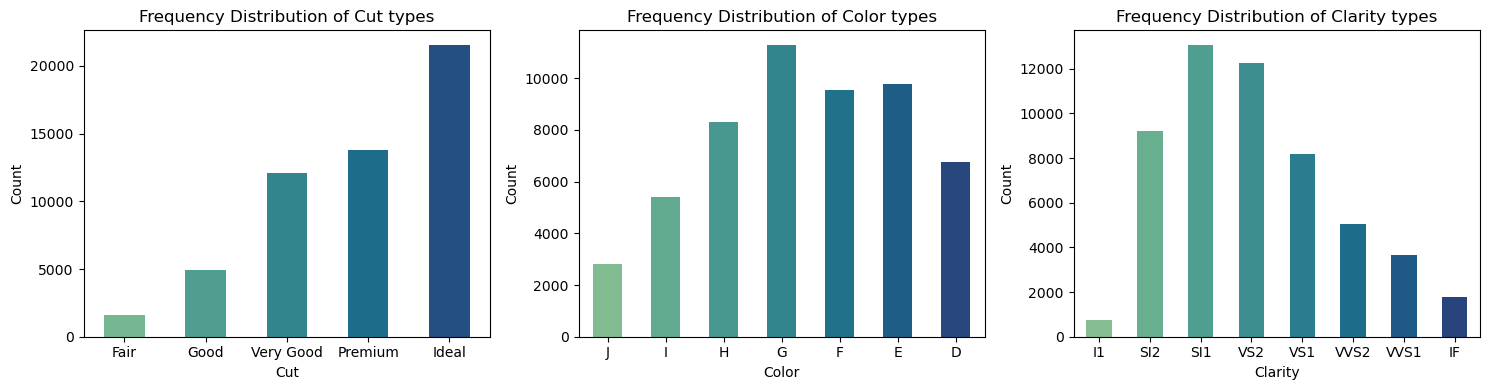

In [8]:
# Visualising frequency distribution of categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, order in zip(axes, ['cut', 'color', 'clarity'], [cut_order, color_order, clarity_order]):
    counts = df[col].value_counts().reindex(order)
    counts.plot(kind="bar", ax=ax, color=sns.color_palette('crest', len(order)))
    ax.set_title(f'Frequency Distribution of {col.capitalize()} types')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 1.3 Distribution of Numerical Variables

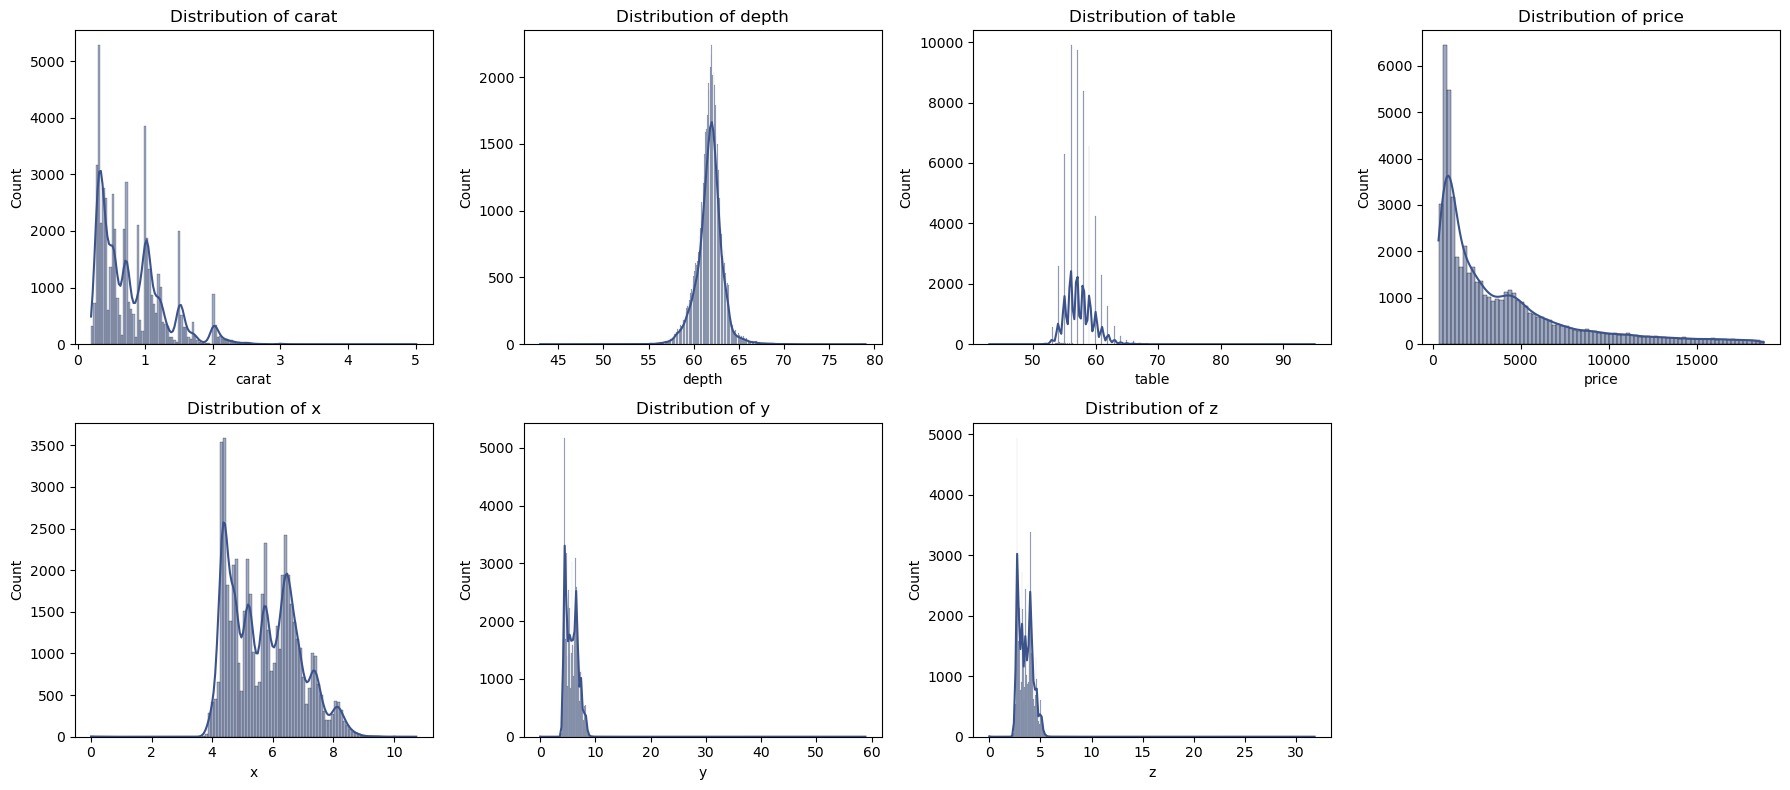

In [9]:
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()  #To convert our 2D grid into a flat list
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#3b528b')
    ax.set_title(f'Distribution of {col}')
axes[-1].axis('off') 
plt.tight_layout()
plt.show()

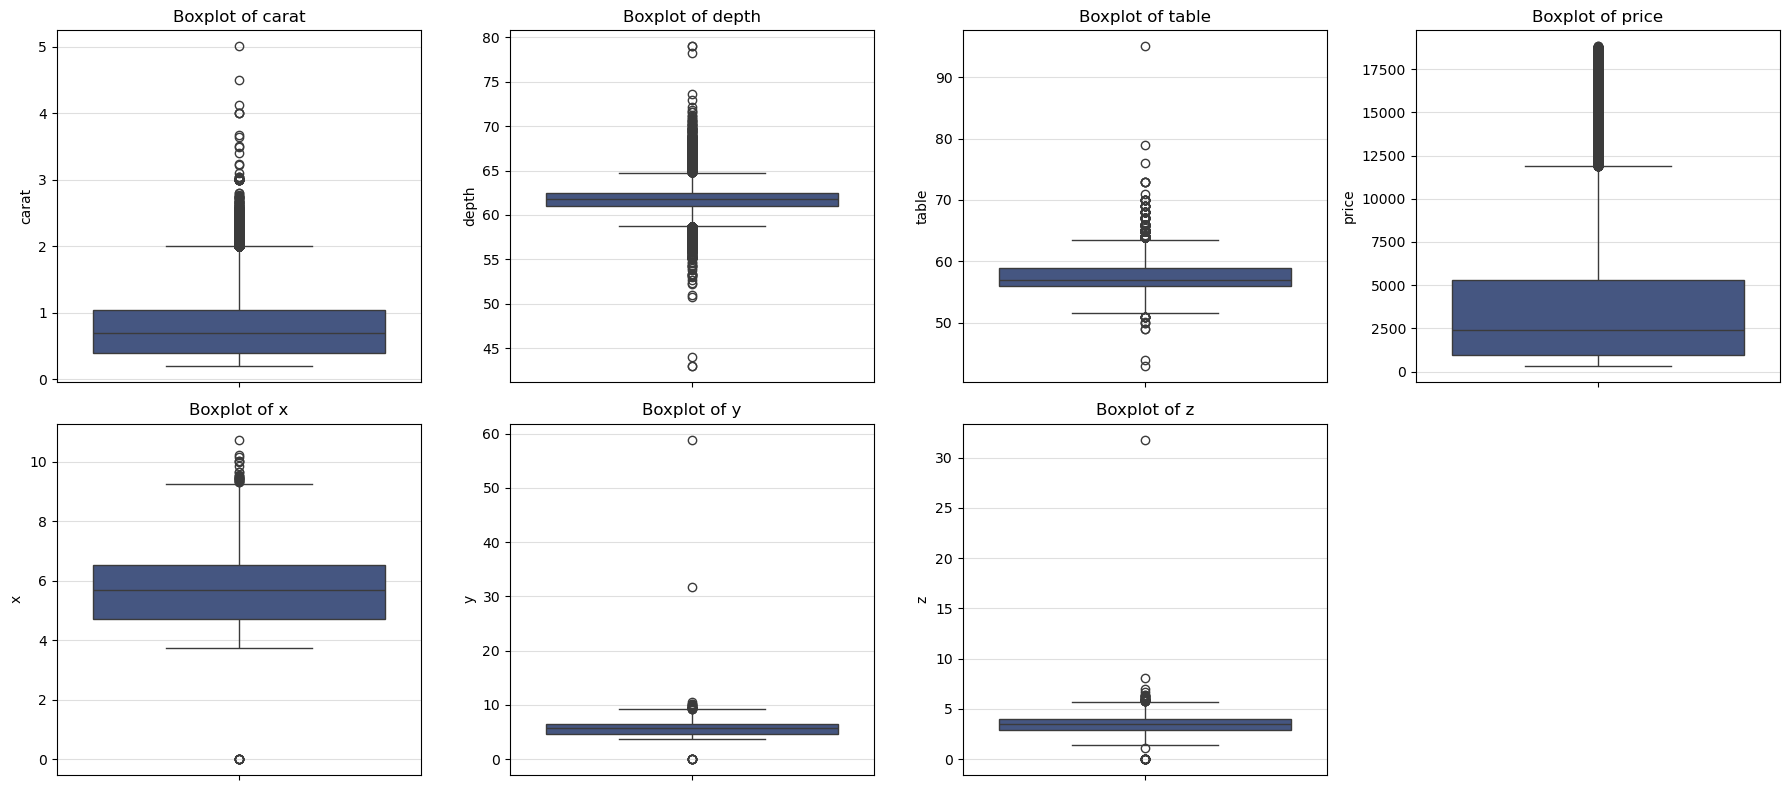

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#3b528b')
    ax.set_title(f'Boxplot of {col}')
    ax.grid(axis='y', alpha=0.25, color='gray')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

#### Observations:
- `carat` and `price` are both right-skewed with long tails of larger/pricier diamonds. A log transform may help for modeling later.
- `depth` and `table` look approximately normal but show visible outliers on both ends in the boxplots.
- `y` and `z` have extreme outliers far beyond the rest of the distribution which does not seem realistic. These, along with the zero values, will be treated as data quality issues later.

### 1.4 Relationships Between Variables

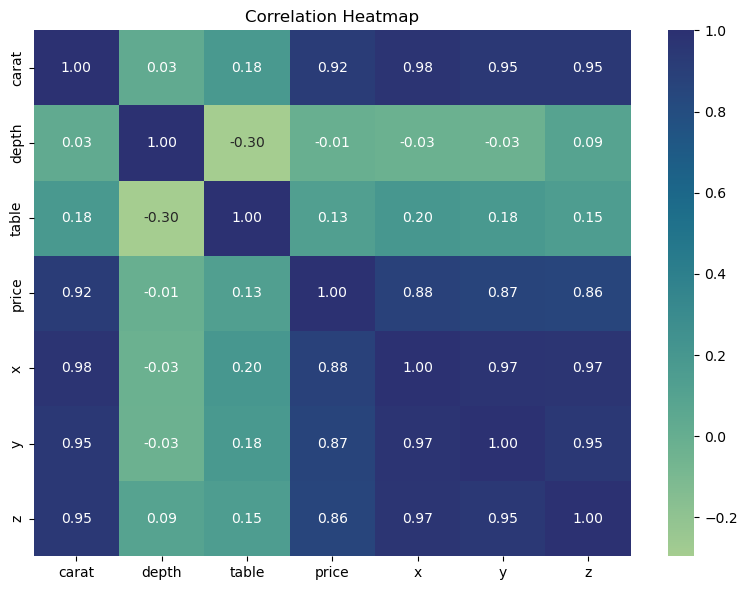

In [11]:
#Visualising Correlation Heatmap

correlation = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='crest')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#### Observations:
- `carat`, `x`, `y`, `z` are all very strongly correlated with each other and each is very strongly correlated with `price`.
- `depth` and `table` show weak correlations with `price` and with each other as they capture shape rather than size.
- The very high correlation among `carat`, `x`, `y`, `z` signals a multicollinearity concern to address later.

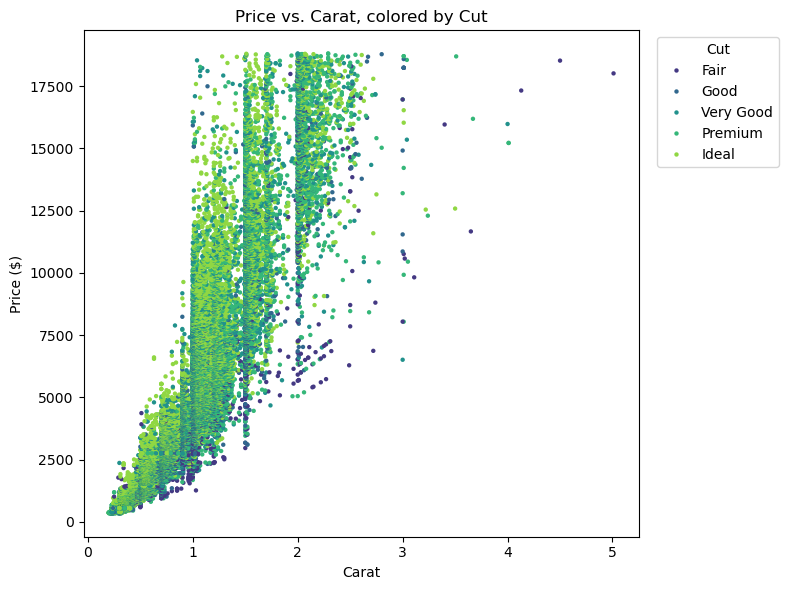

In [12]:
#Visualising our main relationship (Price vs Carat)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='carat', y='price', hue='cut', hue_order=cut_order, palette='viridis', s=10, linewidth=0)
plt.title('Price vs. Carat, colored by Cut')
plt.xlabel('Carat')
plt.ylabel('Price ($)')
plt.legend(title='Cut', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Observations:
- `price` rises with `carat` in a clearly non-linear pattern — variance in price grows sharply as carat increases, and clusters/bands are visible around "round" carat values like 1.0, 1.5, 2.0 which can be inferred that it may be due to commercial reasons.
- Carat is not evenly distributed across categories (i.e.we can see each category of `cut` across different values of `carat`), so cut/color/ clarity's true effect on price is only clear once carat is controlled for, thats's something we'll examine in the regression models.

### 1.5 Data Quality Issues: Missing Values and Outliers

##### Missing Values Check

In [13]:
missing = df.isnull().sum()
print(missing)

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


No `NaN` values are reported anywhere in the dataset. However, a standard `isnull()` check only catches values explicitly marked as missing and does not catch 'disguised' missing values, such as physically impossible measurements recorded as 0. We check for those next.

##### Zero-dimensions Check

In [14]:
zero_values = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)
df[zero_values]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


A diamond cannot have a length, width, or depth of `0` mm — these are measurement/data-entry errors, not real values.  
**Decision:** Since these rows make up only little part of the dataset (20 out of 53,940 rows), and we have no reliable way to impute the true dimensions, we drop them rather than risk introducing fabricated values.

##### Duplicate Rows

In [15]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head()

Duplicate rows: 146


,carat,cut,color,clarity,depth,table,price,x,y,z
43995,0.3,Good,J,VS1,63.4,57.0,394,4.23,4.26,2.69
47296,0.3,Good,J,VS1,63.4,57.0,394,4.23,4.26,2.69
34408,0.3,Ideal,G,IF,62.1,55.0,863,4.32,4.35,2.69
34422,0.3,Ideal,G,IF,62.1,55.0,863,4.32,4.35,2.69
28592,0.3,Ideal,G,VS2,63.0,55.0,675,4.31,4.29,2.71


146 rows are complete duplicates, given that `price` is unlikely to coincidentally match to the dollar for two unrelated diamonds that also share every other attribute, these are almost certainly duplicate records rather than genuinely distinct diamonds.  
**Decision:** Drop duplicates, keeping the first occurrence as they would otherwise let a handful of records be double-counted, subtly biasing any model that treats each row as an independent observation.

##### Extreme Outliers in Dimensions (x, y, z)

In [16]:
#Listing rows with unusually large value of y and z (approx > 20, which is roughly twice the x-dimension's max value
df[(df['y'] > 20) | (df['z'] > 20)]

,carat,cut,color,clarity,depth,table,price,x,y,z
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
48410,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.80
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12


Three rows have a `y` or `z` value unusually large compared to the x-dimension which is not plausible for a real diamond.  
**Decision:** To drop these 3 rows rather than guess-correct them, since we cannot know the intended true value with confidence.

##### Cleaning the Data

In [17]:
df = df.drop_duplicates() #Removing duplicate copies while keeping the original row
df = df[~((df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0))] # '~' flips True values to False and which is dropped, leaving data with True value
df = df[~((df['y'] > 20) | (df['z'] > 20))]
df = df.reset_index(drop=True)
print(f'Final cleaned up entries: {len(df)}')

Final cleaned up entries: 53772


In total we removed 169 rows, a negligible loss that meaningfully improves data quality without discarding any genuine entries. 

### 1.6 Encoding Categorical Variables


`cut`, `color`, and `clarity` are **ordinal** categorical variables. We therefore use **ordinal encoding**, mapping each grade to an integer that preserves its rank.

In [18]:
cut_map = {cat: i for i, cat in enumerate(cut_order)}
color_map = {cat: i for i, cat in enumerate(color_order)}
clarity_map = {cat: i for i, cat in enumerate(clarity_order)}

df['cut_encoded'] = df['cut'].map(cut_map)
df['color_encoded'] = df['color'].map(color_map)
df['clarity_encoded'] = df['clarity'].map(clarity_map)

df[['cut', 'cut_encoded', 'color', 'color_encoded', 'clarity', 'clarity_encoded']].sample(10, random_state=5)

,cut,cut_encoded,color,color_encoded,clarity,clarity_encoded
4656,Ideal,4,E,5,SI1,2
21620,Premium,3,G,3,SI1,2
49140,Ideal,4,I,1,VVS2,5
18964,Very Good,2,J,0,VS2,3
21449,Premium,3,E,5,SI2,1
21876,Ideal,4,F,4,VS2,3
17072,Good,1,E,5,SI1,2
40511,Good,1,H,2,SI1,2
860,Premium,3,J,0,SI1,2
28348,Ideal,4,D,6,SI1,2


### 1.7 Feature Transformations

##### Log Tranformation
Both `price` and `carat` are strongly right-skewed (Section 1.3). For linear regression this matters because it violates the assumption of normally-distributed data. We saw this directly in the non-linear price-vs-carat scatter plot in Section 1.4, where the spread of price grows sharply as carat increases. A log-transform compresses the long right tail and tends to turn into linear relationships.

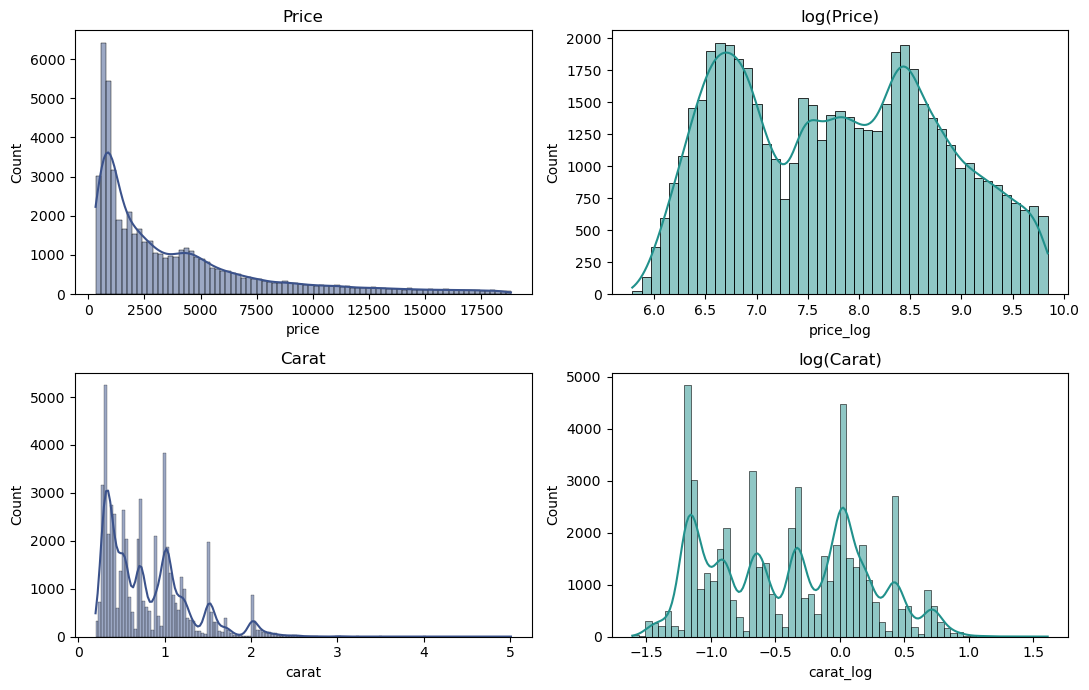

In [19]:
df['price_log'] = np.log(df['price'])
df['carat_log'] = np.log(df['carat'])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
sns.histplot(df['price'], kde=True, ax=axes[0, 0], color='#3b528b')
axes[0, 0].set_title(f"Price")
sns.histplot(df['price_log'], kde=True, ax=axes[0, 1], color='#21918c')
axes[0, 1].set_title(f"log(Price)")
sns.histplot(df['carat'], kde=True, ax=axes[1, 0], color='#3b528b')
axes[1, 0].set_title(f"Carat")
sns.histplot(df['carat_log'], kde=True, ax=axes[1, 1], color='#21918c')
axes[1, 1].set_title(f"log(Carat)")
plt.tight_layout()
plt.show()

The log-transform brings both distributions much closer to symmetric (reduction in right-skewness).  
**Decision:** We are keeping both columns in the dataframe. We'll compare models built on them later, since the log values are believed to satisfy the linear regression assumptions better.

### 1.8 Extended Correlation Ananlysis (including encoded variables)

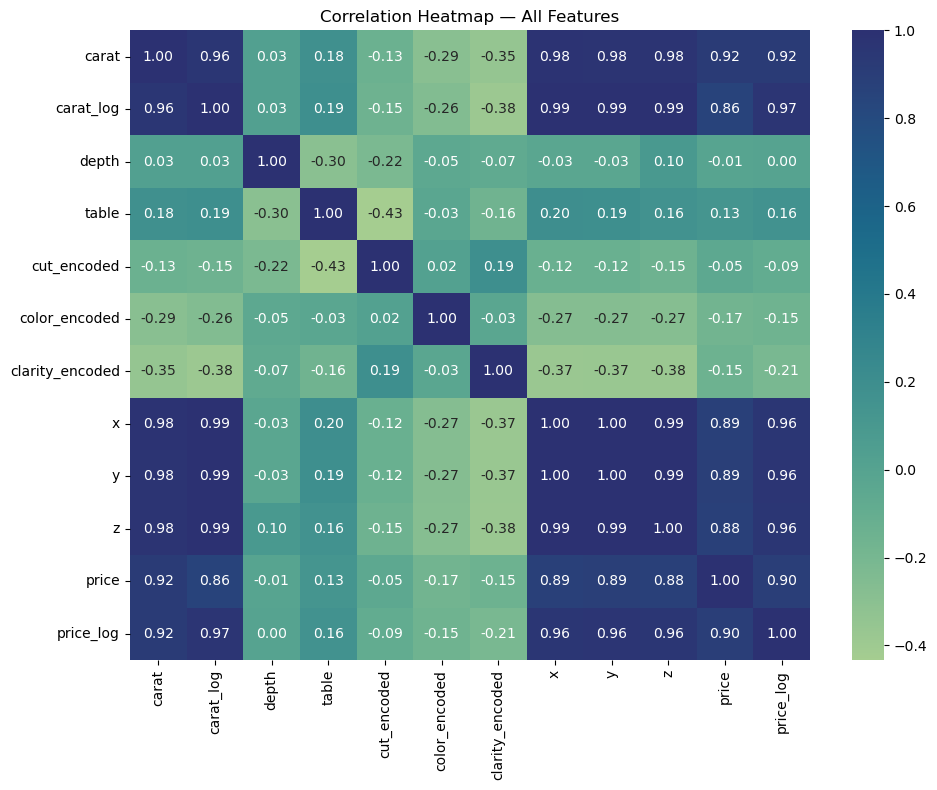

In [20]:
extended_cols = ['carat', 'carat_log', 'depth', 'table', 'cut_encoded', 'color_encoded', 'clarity_encoded', 'x', 'y', 'z', 'price', 'price_log']

correlation_ext = df[extended_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_ext, annot=True, fmt='.2f', cmap='crest')
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.show()

#### Observations:
- Size features (`carat`, `x`, `y`, `z`) remain by far the strongest predictors of `price`.
- `clarity_encoded` and `color_encoded` show weak *positive* correlations with `price` much weaker than their intuitive importance to a jeweler would suggest. This confirms the confounding effect observed in Section 1.4: cut/color/clarity's true effect on price is masked by the fact that carat varies independently of them across the dataset. Their effect will likely become clearer as *coefficients in a multivariate regression* (holding carat constant) later, rather than as raw correlations.
- `cut_encoded` correlates only very weakly (and even slightly negatively) with `price`., Again likely a confounding effect rather than evidence that cut quality doesn't matter to price.
- `depth` remains essentially uncorrelated with `price`, reinforcing that it's unlikely to be a useful standalone predictor.
- `price_log` shows a very similar correlation pattern to `price`, with slightly higher correlations against `carat_log` in particular (0.97 compared to earlier coefficient of 0.92).

This closes out Part 1. The cleaned, encoded, and transformed `df` is now ready to carry into  Model Development and Validation.

## Part 2: Model Development and Validation

With the data cleaned, encoded, and transformed, we now build and validate regression models that explain and predict `price`. Things we will achieve in this part: 

1. Split the data so every model can be judged on genuinely unseen data.
2. Examine correlations among predictors and diagnose multicollinearity, then consider dimensionality reduction (PCA) as one possible response.
3. Develop multiple models that vary both predictor sets and target transformations.
4. Compare the models and identify influential features and observations, which predictors drive price, and which individual diamonds disproportionately shape the model.
5. Select a best model with a justification that weighs accuracy, robustness, and interpretability together.

### 2.1 Train/Test Split

Every model below is fit **only on the training data**. The test set stays untouched until Section 2.5, so our evaluation reflects genuine performance rather than how well a model memorized what it was fit on.

In [21]:
from sklearn.model_selection import train_test_split

predictor_cols_full = ['carat', 'depth', 'table', 'x', 'y', 'z','cut_encoded', 'color_encoded', 'clarity_encoded']

X = df[predictor_cols_full]
y_price = df['price']
y_log_price = df['price_log'] # Using both target and tranformed target variable to be used in different models.

# 80/20 split of the data is selected for the modelling.
X_train, X_test, y_train, y_test, y_log_train, y_log_test = train_test_split(X, y_price, y_log_price, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 43017 rows
Test set:     10755 rows


### 2.2 Examining Correlations Among Predictors

Here we look specifically at how the **predictors relate to each other**. This is what actually drives multicollinearity in a regression, since it's about redundancy *between predictors*, not their individual relationship with the target.

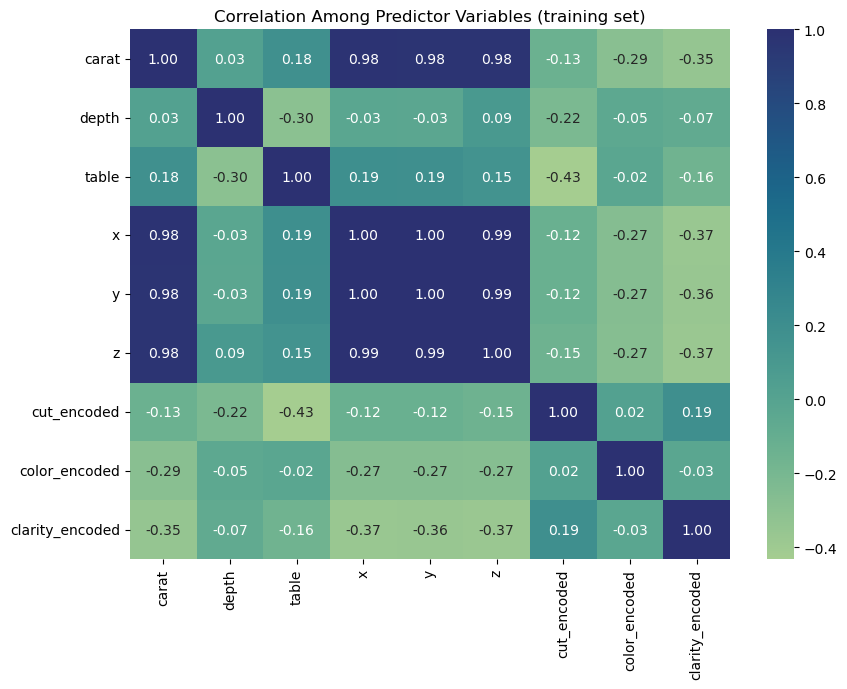

In [22]:
predictor_correlation = X_train.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(predictor_correlation, annot=True, fmt='.2f', cmap='crest')
plt.title('Correlation Among Predictor Variables (training set)')
plt.tight_layout()
plt.show()

`carat`, `x`, `y`, and `z` are extremely correlated with each other (all > 0.98), while everything else is only weakly related to other predictors. Pairwise correlation only captures *two-way* relationships, though a predictor can be redundant with some combination of the others without showing a single high pairwise value.  
For that we use the **Variance Inflation Factor (VIF)**: It regresses each predictor on all the others and measures how much its variance is "inflated" by that redundancy. Rule of thumb: VIF > 10 is severe, 5–10 is a moderate concern, and values near 1 mean little to no redundancy.

In [23]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(X_data):
    X_c = sm.add_constant(X_data)
    v = pd.DataFrame({
        'feature': X_c.columns,
        'VIF': [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]})
    return v[v['feature'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)

vif_full = vif_table(X_train[predictor_cols_full])
vif_full

,feature,VIF
0,y,509.712696
1,x,492.909362
2,z,376.472335
3,carat,25.411138
4,depth,7.055128
5,table,1.628206
6,cut_encoded,1.500802
7,clarity_encoded,1.237077
8,color_encoded,1.119440


`x`, `y`, `z` show extremely high VIF, and `carat` also clears the "severe" threshold of 10, confirming these four features carry almost entirely overlapping size information. `depth` sits at a moderate ~7. `table` and the three encoded grade variables are all close to 1–1.6 — essentially independent of the other predictors. This is a diagnosis, not yet a fix as it directly motivates the next two sections.

### 2.3 Considering Dimensionality Reduction

Given the near-total redundancy among `carat`, `x`, `y`, and `z`, three options are worth testing rather than assuming:
- Keep `carat` only, dropping `x`/`y`/`z` — simple and interpretable, since `carat` is the industry-standard size summary.
- **PCA** on the four size features, collapsing them into fewer, uncorrelated components.
- **Ridge regression** on the full feature set — instead of removing anything, shrink and stabilize the coefficients of the redundant features via regularization.

We'll build a model for each of these and let the evidence in Section 2.5–2.6 decide which is actually the better fix. First, lets look at how much of the shared variance does a single principal component actually capture?

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

size_features = ['carat', 'x', 'y', 'z']

scaler_size = StandardScaler().fit(X_train[size_features])
size_scaled_train = scaler_size.transform(X_train[size_features])
size_scaled_test = scaler_size.transform(X_test[size_features])

pca_full = PCA(random_state=5).fit(size_scaled_train)
print("Explained variance ratio per component:", np.round(pca_full.explained_variance_ratio_, 4))
print("Cumulative variance explained:", np.round(np.cumsum(pca_full.explained_variance_ratio_), 4))

Explained variance ratio per component: [9.89e-01 7.70e-03 3.00e-03 3.00e-04]
Cumulative variance explained: [0.989  0.9967 0.9997 1.    ]


A single component captures **98.9%** of the variance across `carat`, `x`, `y`, `z`. Strongly confirms that these four columns really measure one underlying "size" dimension. We build a model using just this first component `size_pc1` in place of the four raw size features.

In [25]:
pca_1 = PCA(n_components=1, random_state=42).fit(size_scaled_train)

size_pc1_train = pca_1.transform(size_scaled_train).flatten()
size_pc1_test = pca_1.transform(size_scaled_test).flatten()

X_train_pca = X_train.drop(columns=size_features).copy()
X_train_pca['size_pc1'] = size_pc1_train
X_test_pca = X_test.drop(columns=size_features).copy()
X_test_pca['size_pc1'] = size_pc1_test

### 2.4 Developing Multiple Regression Models

We fit five candidate models, deliberately varying the predictor set and the target transformation so thecomparison stage has real, meaningfully different alternatives:

| Model | Predictors | Target | Approach |
|---|---|---|---|
| **1** | All 9 raw features | `price` | Baseline — no fixes, no transforms |
| **2** | All 9 raw features | `log(price)` | Tests the log-transform from Section 1.8 |
| **3** | `carat` instead of `x`/`y`/`z` (6 features) | `log(price)` | Fixes multicollinearity by dropping features |
| **4** | `size_pc1` instead of `carat`/`x`/`y`/`z` (6 features) | `log(price)` | Fixes multicollinearity via dimensionality reduction |
| **5** | All 9 raw features, **Ridge regression** | `log(price)` | Fixes multicollinearity via regularization |


In [26]:
def fit_data(X_data, y_data):
    X_const = sm.add_constant(X_data)
    return sm.OLS(y_data, X_const).fit()

reduced_features = ['carat', 'depth', 'table', 'cut_encoded', 'color_encoded', 'clarity_encoded']
pca_features = ['size_pc1', 'depth', 'table', 'cut_encoded', 'color_encoded', 'clarity_encoded']

models = {
    'Model 1: Full features -> price': fit_data(X_train[predictor_cols_full], y_train),
    'Model 2: Full features -> log(price)': fit_data(X_train[predictor_cols_full], y_log_train),
    'Model 3: carat only -> log(price)': fit_data(X_train[reduced_features], y_log_train),
    'Model 4: PCA size component -> log(price)': fit_data(X_train_pca[pca_features], y_log_train)}
print("Models 1-4 fitted.")

Models 1-4 fitted.


In [27]:
from sklearn.linear_model import RidgeCV

scaler_full = StandardScaler().fit(X_train[predictor_cols_full])
X_train_scaled = scaler_full.transform(X_train[predictor_cols_full])
X_test_scaled = scaler_full.transform(X_test[predictor_cols_full])

# 5-fold cross validation is considered due to the size of our data as the 5 (alongside 10-fold) are the most common practice.
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_scaled, y_log_train)
print(f"Model 5 (Ridge) fitted. Best alpha selected via 5-fold CV: {ridge_model.alpha_:.3f}")

Model 5 (Ridge) fitted. Best alpha selected via 5-fold CV: 10.985


##### Summary of Models

In [28]:
print(models['Model 1: Full features -> price'].summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                 4.767e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:54:52   Log-Likelihood:            -3.6626e+05
No. Observations:               43017   AIC:                         7.325e+05
Df Residuals:                   43007   BIC:                         7.326e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -4284.4099    753.151     

In [29]:
print(models['Model 2: Full features -> log(price)'].summary())

                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 2.254e+05
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:54:52   Log-Likelihood:                 21635.
No. Observations:               43017   AIC:                        -4.325e+04
Df Residuals:                   43007   BIC:                        -4.316e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.3461      0.091    -

In [30]:
print(models['Model 3: carat only -> log(price)'].summary())

                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                 5.374e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:54:52   Log-Likelihood:                -15680.
No. Observations:               43017   AIC:                         3.137e+04
Df Residuals:                   43010   BIC:                         3.143e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.3033      0.122     

In [31]:
print(models['Model 4: PCA size component -> log(price)'].summary())

                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                 1.532e+05
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:54:53   Log-Likelihood:                 5144.5
No. Observations:               43017   AIC:                        -1.028e+04
Df Residuals:                   43010   BIC:                        -1.021e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               6.2685      0.075     

**Model 5 (Ridge) doesn't have a `.summary()` in the same sense** — `scikit-learn`'s Ridge implementation doesn't compute the classical standard errors, t-statistics, or p-values that `statsmodels`' OLS does. The closest equivalent is simply its fitted coefficients and intercept:

In [32]:
ridge_coef_table = pd.DataFrame({
    'feature': ['const (intercept)'] + predictor_cols_full,
    'coefficient': [ridge_model.intercept_] + list(ridge_model.coef_)
})
ridge_coef_table

,feature,coefficient
0,const (intercept),7.787326
1,carat,-0.511250
2,depth,0.054192
3,table,0.022067
4,x,0.727036
5,y,0.566164
6,z,0.295817
7,cut_encoded,0.031791
8,color_encoded,0.132634
9,clarity_encoded,0.198044


Now let's check whether Models 3 and 4 actually resolved the multicollinearity that Section 2.2 flagged.

In [33]:
from IPython.display import display

print("VIF - reduced feature set (Model 3):")
vif_reduced = vif_table(X_train[reduced_features])
display(vif_reduced)

VIF - reduced feature set (Model 3):


,feature,VIF
0,table,1.578541
1,cut_encoded,1.481762
2,depth,1.324772
3,carat,1.292502
4,clarity_encoded,1.198609
5,color_encoded,1.117012


In [34]:
print("VIF - PCA feature set (Model 4):")
vif_pca = vif_table(X_train_pca[pca_features])
display(vif_pca)

VIF - PCA feature set (Model 4):


,feature,VIF
0,table,1.575841
1,cut_encoded,1.481816
2,depth,1.324108
3,size_pc1,1.297716
4,clarity_encoded,1.214785
5,color_encoded,1.108404


Both alternative feature sets bring every VIF down to ~1–1.6 which essentially eliminates multicollinearity on paper. Whether that's actually fixes our issue, though, depends on how these models perform which we will check next.

### 2.5 Comparing Models Using Appropriate Statistical Metrics

Model 1 predicts `price` directly, but Models 2–5 predict `log(price)`. Their R² values are *not* comparable as-is as a model can look better on a compressed log scale without actually predicting dollars any better. To compare fairly, we back-transform every log-scale prediction with `exp()` and evaluate **all five models on the test set, in original dollar terms**.

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score

def price_scale_metrics(name, y_true, y_pred):
    return [name,
            np.sqrt(mean_squared_error(y_true, y_pred)),
            mean_absolute_error(y_true, y_pred),
            median_absolute_error(y_true, y_pred),
            r2_score(y_true, y_pred)]

pred1 = models['Model 1: Full features -> price'].predict(sm.add_constant(X_test[predictor_cols_full], has_constant='add'))
pred2 = np.exp(models['Model 2: Full features -> log(price)'].predict(sm.add_constant(X_test[predictor_cols_full], has_constant='add')))
pred3 = np.exp(models['Model 3: carat only -> log(price)'].predict(sm.add_constant(X_test[reduced_features], has_constant='add')))
pred4 = np.exp(models['Model 4: PCA size component -> log(price)'].predict(sm.add_constant(X_test_pca[pca_features], has_constant='add')))
pred5 = pd.Series(np.exp(ridge_model.predict(X_test_scaled)), index=y_test.index)

rows = [
    price_scale_metrics('Model 1: raw -> price', y_test, pred1),
    price_scale_metrics('Model 2: raw -> log(price)', y_test, pred2),
    price_scale_metrics('Model 3: carat only -> log(price)', y_test, pred3),
    price_scale_metrics('Model 4: PCA -> log(price)', y_test, pred4),
    price_scale_metrics('Model 5: Ridge (full, scaled) -> log(price)', y_test, pred5),
]
metrics_df = pd.DataFrame(rows, columns=['Model', 'RMSE ($)', 'MAE ($)', 'Median AE ($)', 'R2'])
metrics_df

,Model,RMSE ($),MAE ($),Median AE ($),R2
0,Model 1: raw -> price,1215.800037,797.908280,572.984141,0.904839
1,Model 2: raw -> log(price),876.756853,457.794332,181.601233,0.950513
2,Model 3: carat only -> log(price),123179.047322,3248.517054,430.570203,-975.801674
3,Model 4: PCA -> log(price),6908.502902,1001.756466,249.108543,-2.072562
4,"Model 5: Ridge (full, scaled) -> log(price)",879.593137,457.758744,181.481854,0.950192


Model 3's RMSE jumps out wildly which is $123,179, that is far worse than even the naive Model 1, and its R² is also wildly negative. Model 4 is also much worse than Models 1, 2, and 5. That's surprising, since Model 3 had a perfectly respectable training R² of 0.88 on the log scale (Section 2.4). 

In [36]:
worst_row = (pred3 - y_test).abs().idxmax()
comparison = pd.DataFrame({
    'actual_price': [y_test.loc[worst_row]],
    'Model 1 pred': [pred1.loc[worst_row]],
    'Model 2 pred': [pred2.loc[worst_row]],
    'Model 3 pred': [pred3.loc[worst_row]],
    'Model 4 pred': [pred4.loc[worst_row]],
    'Model 5 pred': [pred5.loc[worst_row]],
}, index=[f'diamond (carat={X_test.loc[worst_row, "carat"]})'])
comparison.round(0)

,actual_price,Model 1 pred,Model 2 pred,Model 3 pred,Model 4 pred,Model 5 pred
diamond (carat=5.01),18018,41802.0,18318.0,12517297.0,576863.0,19008.0


There it is: for this single 5.01-carat diamond (actual price 18,018), Model 2 and Model 5 predict sensibly (~18,300 and $19,000). Model 1 also misses — predicting 41,800, more than double the true price, since a plain linear fit on raw `price` struggles with the fan-shaped variance we saw back in Section 1.4 (this is exactly why Section 1.8 introduced the log-transform in the first place). But that's a rounding error next to what happens to the "fixed" models: Model 3 predicts over 12.5 million, and Model 4 predicts 577,000. Both go badly wrong on exactly the diamonds that matter most — the rare, high-value ones.

**Why:** `carat` alone isn't perfectly log-linear with price across the *entire* range — the biggest, rarest stones curve away from the typical trend. Models 2 and 5 have `x`, `y`, `z` available to help anchor a precise prediction for an unusual stone's actual proportions; Model 3 and 4 threw that information away specifically to fix multicollinearity, and pay for it with wild extrapolation once `exp()` amplifies a modest log-scale error into an enormous dollar-scale one.

**This is exactly why "appropriate statistical metrics" means more than one number.** RMSE (which squares errors) is dominated by a *handful* of these catastrophic misses. Look at Model 3's Median Absolute Error (431), which is actually reasonable and close to Model 2's. MAE and Median AE tell you the model is fine for *typical* diamonds, while RMSE tells you it occasionally fails catastrophically. Neither alone is "the" answer, using both together is what reveals this trade-off at all.

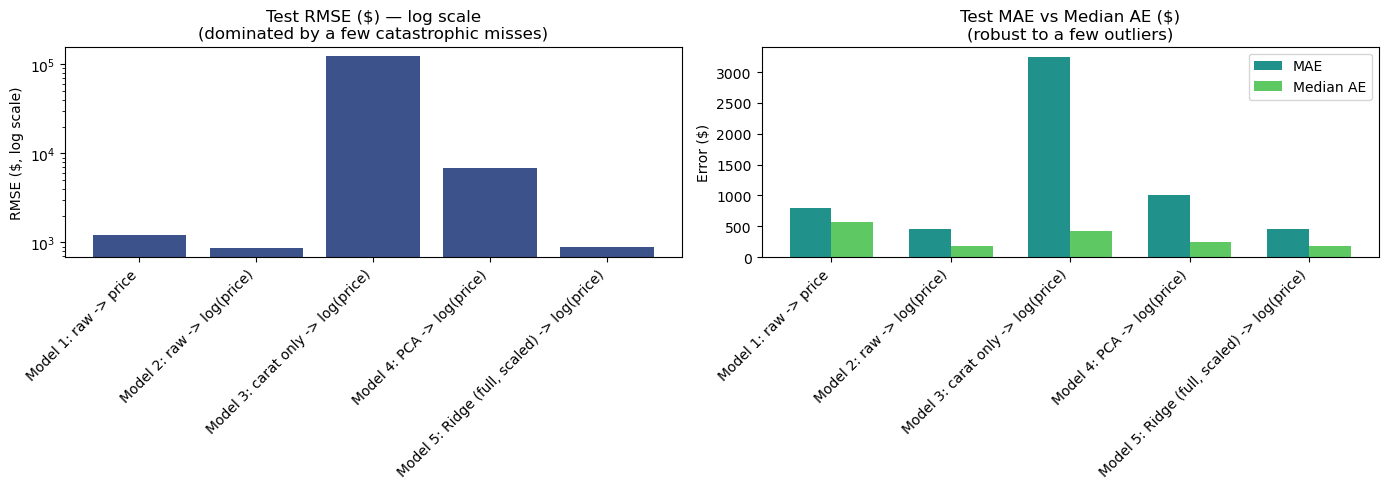

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(metrics_df['Model'], metrics_df['RMSE ($)'], color='#3b528b')
axes[0].set_yscale('log')
axes[0].set_title('Test RMSE ($) — log scale\n(dominated by a few catastrophic misses)')
axes[0].set_ylabel('RMSE ($, log scale)')
axes[0].tick_params(axis='x', rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha('right')

x_pos = np.arange(len(metrics_df))
width = 0.35
axes[1].bar(x_pos - width/2, metrics_df['MAE ($)'], width, label='MAE', color='#21918c')
axes[1].bar(x_pos + width/2, metrics_df['Median AE ($)'], width, label='Median AE', color='#5ec962')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics_df['Model'], rotation=45, ha='right')
axes[1].set_title('Test MAE vs Median AE ($)\n(robust to a few outliers)')
axes[1].set_ylabel('Error ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

The left panel (log-scale RMSE) shows just how dramatically Models 3 and 4 blow up. The right panel shows that on the typical-diamond metrics (MAE, Median AE), the gap narrows a lot — Model 3's Median AE is actually competitive. Models 2 and 5 are the standouts overall. Both stay accurate on typical diamonds and avoid catastrophic failure on the extreme ones.

### 2.6 Addressing Multicollinearity Concerns

Section 2.2 diagnosed severe multicollinearity (VIF in the hundreds for `x`/`y`/`z`). Section 2.4 confirmed that dropping features (Models 3, 4) does eliminate it on paper. But Section 2.5 just showed that fix has a real, serious cost that is catastrophic mispricing of exactly the diamonds a jeweler would care most about getting right.

So what does multicollinearity actually cost us if we don't drop anything? Not prediction accuracy — Model 2's R² and RMSE were fine.  
The real cost is **coefficient instability**: with `carat`, `x`, `y`, `z` all explaining almost the same variance, OLS struggles to assign credit among them consistently, so the individual coefficient estimates become unreliable, even while the model's overall predictions stay accurate. We can demonstrate this directly by refitting on 20 bootstrap resamples of the training data and looking at how much each coefficient moves around.

In [38]:
from sklearn.linear_model import Ridge


rng = np.random.RandomState(1)
n_boot = 20
ols_boot_coefs, ridge_boot_coefs = [], []

for _ in range(n_boot):
    idxs = rng.choice(X_train.index, size=len(X_train), replace=True)
    Xb, yb = X_train.loc[idxs, predictor_cols_full], y_log_train.loc[idxs]

    ols_boot_coefs.append(fit_data(Xb, yb).params[predictor_cols_full].values)

    Xb_scaled = scaler_full.transform(Xb)
    ridge_boot_coefs.append(Ridge(alpha=ridge_model.alpha_).fit(Xb_scaled, yb).coef_)

ols_boot_df = pd.DataFrame(ols_boot_coefs, columns=predictor_cols_full)
ridge_boot_df = pd.DataFrame(ridge_boot_coefs, columns=predictor_cols_full)

stability = pd.DataFrame({
    'OLS coef std':   ols_boot_df.std(),
    'OLS CV (%)':     100 * ols_boot_df.std() / ols_boot_df.mean().abs(),
    'Ridge coef std': ridge_boot_df.std(),
    'Ridge CV (%)':   100 * ridge_boot_df.std() / ridge_boot_df.mean().abs(),
}).round(2)
stability.loc[['carat', 'x', 'y', 'z', 'depth', 'table', 'cut_encoded', 'color_encoded', 'clarity_encoded']]

,OLS coef std,OLS CV (%),Ridge coef std,Ridge CV (%)
carat,0.01,1.10,0.01,1.10
x,0.07,10.45,0.07,9.38
y,0.07,15.79,0.07,13.43
z,0.20,42.01,0.12,34.20
depth,0.01,32.13,0.01,29.67
table,0.00,4.54,0.00,4.34
cut_encoded,0.00,2.68,0.00,2.61
color_encoded,0.00,0.65,0.00,0.65
clarity_encoded,0.00,0.36,0.00,0.36


**CV (coefficient of variation) = std / |mean|** — the lower it is, the more stable that coefficient is across resamples. The pattern is clear and consistent with the VIF ranking: `z` (the most collinear feature by VIF) is by far the least stable under plain OLS — its estimate swings by about **42% of its own size** across resamples. Ridge cuts that down to about **34%**. `y` and `x` show smaller but consistent improvements too. The features with low VIF to begin with (`table`, `cut_encoded`, `color_encoded`, `clarity_encoded`) are already stable under OLS and barely change under Ridge, exactly as we'd expect if this genuinely is a multicollinearity effect and not just regularization shrinking everything indiscriminately.

**This is how we actually address the multicollinearity concern:** not by discarding `x`, `y`, `z` (which Section 2.5 showed comes at a real accuracy cost on rare, high-value diamonds), but by keeping them and letting Ridge regularization absorb the redundancy, at virtually no cost to predictive accuracy (Model 5's test RMSE/MAE in Section 2.5 were within a rounding error of Model 2's).

### 2.7 Identifying Influential Features and Observations

##### Features that matters the most for predicting price

Raw regression coefficients aren't directly comparable across features on different scales (a coefficient on `carat`, which ranges 0.2–5, isn't on the same footing as one on `table`, which ranges 43–95). Since Model 5's predictors were standardized before fitting, its coefficients are already standardized so we can rank them directly as a measure of relative feature importance.

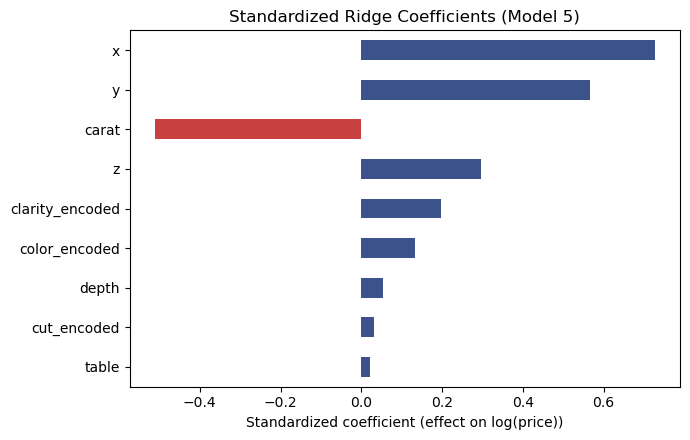

x                  0.727036
y                  0.566164
carat             -0.511250
z                  0.295817
clarity_encoded    0.198044
color_encoded      0.132634
depth              0.054192
cut_encoded        0.031791
table              0.022067
dtype: float64

In [39]:
ridge_importance = pd.Series(ridge_model.coef_, index=predictor_cols_full).sort_values(key=abs, ascending=False)

plt.figure(figsize=(7, 4.5))
colors = ['#3b528b' if v > 0 else '#c94040' for v in ridge_importance.values]
ridge_importance.plot(kind='barh', color=colors)
plt.title("Standardized Ridge Coefficients (Model 5)")
plt.xlabel('Standardized coefficient (effect on log(price))')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ridge_importance

`x` (length) carries the largest standardized effect, followed by `y` (width) and `carat`. This might look odd at first as didn't we just say these are redundant? They are, but Ridge doesn't eliminate a redundant predictor's contribution, it distributes the shared size-effect across `carat`, `x`, `y`, and `z` rather than concentrating it in one. Together, the four size-related features dominate; `clarity_encoded` and `color_encoded` are the next most influential (matching their status as genuine, if secondary, price drivers once size is accounted for), and `table`/`cut_encoded` contribute the least.

##### Individual entries affecting the model

Beyond which features matter, it's worth checking whether a handful of individual rows are disproportionately shaping the fit.  
**Cook's Distance** measures how much the model's fitted values would change if a given observation were removed — a standard OLS diagnostic, computed here on Model 2 (the full-feature log model).

In [40]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(models['Model 2: Full features -> log(price)'])
cooks_d = influence.cooks_distance[0]
n_train = len(cooks_d)
threshold = 4 / n_train
n_flagged = (cooks_d > threshold).sum()

print(f"Cook's Distance threshold (4/n): {threshold:.6f}")
print(f"Points above threshold: {n_flagged} ({100*n_flagged/n_train:.2f}% of training data)")
print(f"Maximum Cook's Distance: {cooks_d.max():.4f}")

Cook's Distance threshold (4/n): 0.000093
Points above threshold: 1916 (4.45% of training data)
Maximum Cook's Distance: 1.5451


4.45% of points technically clear the classic `4/n` threshold — but with over 40,000 training rows, that threshold is extremely small by construction and flags far more points than which are genuinely influential in any practical sense. It's more informative to look directly at the small number of points with by far the largest Cook's Distance.

In [41]:
train_with_cooks = X_train[predictor_cols_full].copy()
train_with_cooks['cooks_d'] = cooks_d

top_influential = train_with_cooks.sort_values('cooks_d', ascending=False).head(6)
top_influential

,carat,depth,table,x,y,z,cut_encoded,color_encoded,clarity_encoded,cooks_d
20642,1.53,61.9,54.0,7.43,7.50,1.53,4,1,2,1.545059
14594,1.07,60.6,57.0,6.62,6.67,1.07,4,4,2,1.426018
21600,1.41,60.7,56.0,7.31,7.22,1.41,4,2,4,1.271660
26420,2.06,60.0,60.0,6.29,6.25,4.96,3,2,1,0.860933
25779,2.00,59.0,62.0,6.16,6.15,4.82,3,3,2,0.765309
34167,0.39,61.2,58.0,4.51,6.02,4.44,3,2,1,0.413771


The single most influential point has `carat = 1.53`, `x = 7.43`, `y = 7.50`, but `z = 1.53`. That number looks suspiciously identical to the diamond's `carat` value. The same pattern shows up for two more of the top influential rows (`carat = 1.07, z = 1.07` and `carat = 1.41, z = 1.41`).

Checking whether this is coincidence: the dataset contains many other diamonds sharing the exact same `carat`/`x`/`y` as these three, and all of them have a `z` that lines up closely with what the `depth` percentage formula (`depth = z / mean(x, y) × 100`) implies. Only these three rows break that pattern, and in each case, the "broken" `z` is exactly equal to the diamond's `carat`. That's a strong, specific signature of a **data-entry error**: it looks like the `carat` value was accidentally copied into the `z` field for these 3 rows.

In [42]:
# Cross-check: for the 3 flagged rows, does the recorded z match what depth/x/y implies?
flagged_signature = df[
    ((df['carat'] == 1.53) & (df['x'] == 7.43) & (df['z'] == 1.53)) |
    ((df['carat'] == 1.07) & (df['x'] == 6.62) & (df['z'] == 1.07)) |
    ((df['carat'] == 1.41) & (df['x'] == 7.31) & (df['z'] == 1.41))
].copy()
flagged_signature['expected_z_from_depth'] = flagged_signature['depth'] / 100 * flagged_signature[['x', 'y']].mean(axis=1)
flagged_signature[['carat', 'depth', 'table', 'x', 'y', 'z', 'expected_z_from_depth']]

,carat,depth,table,x,y,z,expected_z_from_depth
14594,1.07,60.6,57.0,6.62,6.67,1.07,4.026870
20642,1.53,61.9,54.0,7.43,7.50,1.53,4.620835
21600,1.41,60.7,56.0,7.31,7.22,1.41,4.409855


This is a genuinely useful example of diagnostics feeding back into data quality: Part 1's range-based checks (Section 1.5) caught **blatant** errors (zeros, values >20mm) but had no way to catch a value that's merely wrong for that specific row while still looking like a plausible diamond dimension in isolation. 

**Decision:** since the correct value is confidently recoverable from the `depth`/`x`/`y` relationship (as shownabove), we correct these 3 rows here rather than discard them. Given it's 3 rows out of 43,017 trainingobservations, this has a negligible effect on the fitted models above — we're not re-running the full model suite for it, but it's documented here as a follow-up refinement to Part 1's data cleaning, worth folding into the cleaning step directly in any future iteration of this analysis.

In [43]:
for idx in flagged_signature.index:
    correct_z = flagged_signature.loc[idx, 'expected_z_from_depth']
    df.loc[idx, 'z'] = correct_z

print("Corrected the 3 mis-recorded z values using the depth/x/y relationship.")
df.loc[flagged_signature.index, ['carat', 'depth', 'x', 'y', 'z']]

Corrected the 3 mis-recorded z values using the depth/x/y relationship.


,carat,depth,x,y,z
14594,1.07,60.6,6.62,6.67,4.026870
20642,1.53,61.9,7.43,7.50,4.620835
21600,1.41,60.7,7.31,7.22,4.409855


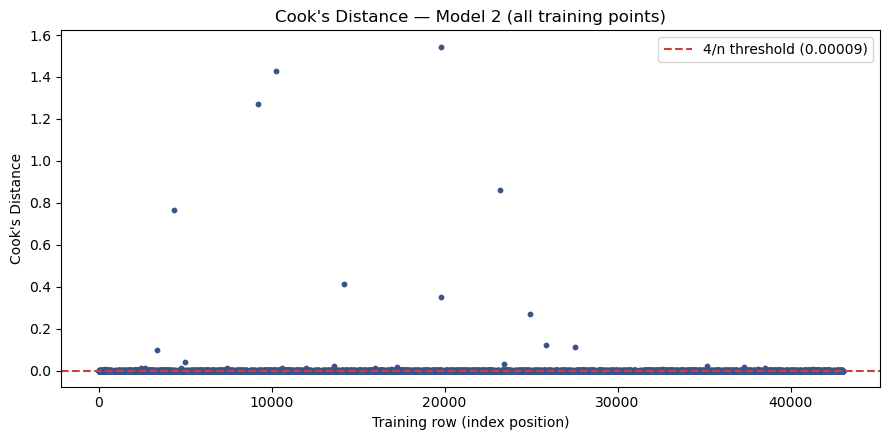

In [44]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(range(len(cooks_d)), cooks_d, s=10, color='#3b528b')
ax.axhline(threshold, color='#c94040', linestyle='--', label=f"4/n threshold ({threshold:.5f})")
ax.set_title("Cook's Distance — Model 2 (all training points)")
ax.set_xlabel('Training row (index position)')
ax.set_ylabel("Cook's Distance")
ax.legend()
plt.tight_layout()
plt.show()

A small number of points stand well above the rest and these are the ones worth a closer look individually, exactly as we just did, rather than the broader 4.45% flagged by the blanket threshold.

### 2.8 Model Comparison Summary and Best Model Selection

| Model | Test RMSE (dollars) | Test MAE (dollars) | Test Median AE (dollars) | Test R² | Multicollinearity | Notes |
|---|---|---|---|---|---|---|
| 1: raw → price | 1,215.80 | 797.91 | 572.98 | 0.905 | Severe (unaddressed) | Weakest overall fit; no transform |
| 2: raw → log(price) | 876.76 | 457.79 | 181.60 | 0.951 | Severe (unaddressed) | Best raw accuracy, but coefficients unstable |
| 3: carat only → log(price) | 123,179.05 | 3,248.52 | 430.57 | −975.8 | Fixed (VIF ≈ 1) | Fine for typical diamonds; catastrophic on rare large ones |
| 4: PCA size → log(price) | 6,908.50 | 1,001.76 | 249.11 | −2.07 | Fixed (VIF ≈ 1) | Same failure mode as Model 3, less severe |
| **5: Ridge (full, scaled) → log(price)** | **879.59** | **457.76** | **181.48** | **0.950** | **Meaningfully reduced** | **Matches Model 2's accuracy, more stable coefficients** |

**Selected model: Model 5 (Ridge regression, full feature set, `log(price)` target).**

**Justification:**
- **Accuracy:** Its test RMSE, MAE, and Median AE are essentially tied with Model 2 (the best-performing OLS model).
- **Robustness:** Unlike Model 2, it directly addresses the severe multicollinearity flagged by VIF. Section 2.6 showed a real, measurable reduction in coefficient instability (e.g. `z`'s bootstrap CV dropped from ~42% to ~34%), without discarding any physically meaningful predictor.
- **Avoids the failure mode of Models 3 and 4:** Both alternative "fixes" for multicollinearity looked clean on VIF but catastrophically mispriced the rarest, most valuable diamonds once evaluated properly (Section 2.5), precisely because they discarded the `x`/`y`/`z` information needed to get those cases right. Model 5 keeps that information.
- **Interpretability trade-off, acknowledged honestly:** Model 5 doesn't give classical p-values the way an OLS model does, and because it distributes the size-effect across four correlated features (Section 2.7) rather than isolating it in one, individual coefficients are harder to interpret in isolation than in Model 3. If the priority were pure statistical inference on a single "effect of carat" coefficient, Model 2 (with robust standard errors) or Model 3 would be more appropriate. For a model whose job is producing reliable price predictions, including for the rare, expensive diamonds that matter most — Model 5 is the better choice.

## Part 3: Interpretation and Insights

### 3.1 Key Findings and Patterns

**Size is overwhelmingly the primary driver of price.** `carat`, `x`, `y`, and `z` all correlate with `price`, and together dominate the standardized coefficients of our best model (Section 2.7). This isn't a surprising result on its own but the degree to which size features overshadow everything else is a useful, concrete takeaway.

**Naive fixes for multicollinearity can silently break a model on the cases that matter most.** This was the most important pattern to emerge from Part 2. Both alternative "fixes" for the `carat`/`x`/`y`/`z` redundancy (Models 3 and 4) had excellent VIF and reasonable training R². It took evaluating them specifically on rare, extreme cases in dollar terms to reveal they were extrapolating wildly for the largest diamonds. A model can look statistically sound in aggregate while still failing badly in exactly the region a business would care most about getting right.

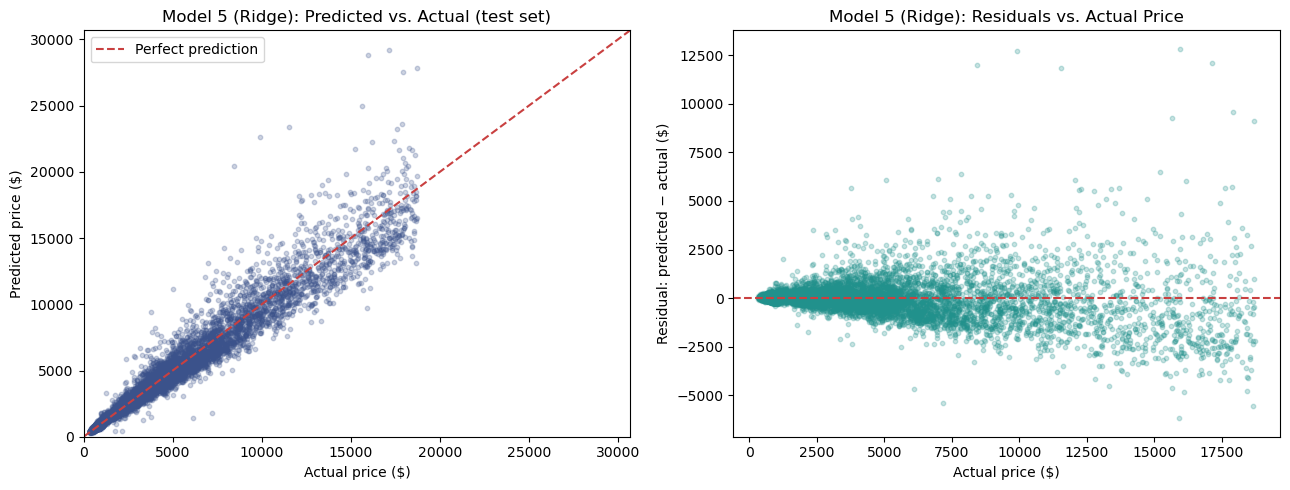

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, pred5, alpha=0.25, s=10, color='#3b528b')
lims = [0, max(y_test.max(), pred5.max()) * 1.05]
axes[0].plot(lims, lims, color='#c94040', linestyle='--', label='Perfect prediction')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual price ($)')
axes[0].set_ylabel('Predicted price ($)')
axes[0].set_title('Model 5 (Ridge): Predicted vs. Actual (test set)')
axes[0].legend()

residuals_dollar = pred5 - y_test
axes[1].scatter(y_test, residuals_dollar, alpha=0.25, s=10, color='#21918c')
axes[1].axhline(0, color='#c94040', linestyle='--')
axes[1].set_xlabel('Actual price ($)')
axes[1].set_ylabel('Residual: predicted − actual ($)')
axes[1].set_title('Model 5 (Ridge): Residuals vs. Actual Price')

plt.tight_layout()
plt.show()

The predicted-vs-actual plot shows points hugging the diagonal closely across almost the entire price range, including out toward the more expensive diamonds, a visual confirmation that Model 5 avoids the extrapolation failure Models 3 and 4 suffered. The residual plot shows errors are small and reasonably centered around zero for cheaper diamonds, with a modest fan-out (larger absolute errors) at higher prices — expected, since a small percentage error on a 15,000 dollars diamond is a much bigger dollar error than the same percentage error on a 1,500 one. This is a useful reminder that even our selected model isn't equally precise everywhere, it's simply the most robust of the five we tested.

A data quality issue was still lurking after Part 1's cleaning. Cook's Distance flagged a small number of training points as unusually influential, and three of the very top ones shared an implausible signature, their `z` value exactly matched their `carat` value, inconsistent with every other diamond sharing the same `carat`/`x`/`y`. Part 1's zero/range-based checks had no way to catch this, since 1.53mm is a perfectly plausible-looking number in isolation. It just happened to be wrong for that specific diamond. This shows that data cleaning isn't a one-and-done step early in a project, model diagnostics can surface issues that simple range checks miss.

### 3.2 Practical Implications

- **A defensible starting point for automated pricing.** Model 5 could reasonably support a "suggested price" or "fair value" tool for typical diamonds which is useful for inventory pricing, quick appraisal cross-checks, or flagging listings that are priced well above or below the model's expectation for further review.
- **Simple size-based pricing break down for rare, large stones.** The informal intuition that "price scales roughly with carat" (which is roughly what Model 3 encodes) works fine for typical diamonds but was shown to fail badly at the high end. In practice, this suggests large/rare diamonds should route to specialist appraisal rather than an automated size-based estimate, since the training data simply contains too few examples in that region for any model (even our best one) to be fully trusted there.
- **Influence diagnostics are a genuinely useful, ongoing QA tool and not just a one-time modeling step.** The data-entry error we found via Cook's Distance suggests that periodically re-running this kind of diagnostic against new incoming data (not just once during initial cleaning) could catch mislabeled records that simple validation rules would miss.
- **Grade certificates (cut/color/clarity) genuinely add pricing information beyond size** — modest in magnitude, but real and directionally sensible once carat is controlled for, supporting their continued use as pricing inputs alongside physical measurements.

### 3.3 Limitations

- **Only linear-family models were tested.** Ridge is still fundamentally a straight-line (in log-space) model. The very failure mode that motivated selecting it — `carat` bending away from a straight log-linear trend at the extreme high end which suggests the true relationship has some genuine curvature that no linear model, however well-regularized, can fully capture. A non-linear approach (polynomial terms, or tree-based methods like Random Forest or Gradient Boosting) might handle that region more natively.
- **A single 80/20 train/test split** was used for the final head-to-head model comparison. This is standard practice and was necessary for a fair, untouched evaluation, but results, especially the exact dollar figures in Section 2.5's metrics table could shift somewhat with a different random split. We did use 5-fold cross-validation, but only to select Ridge's `alpha`, not to evaluate final out-of-sample performance broadly.
- **Ordinal encoding assumes equal spacing between grades** (e.g., that `Fair`→`Good` has the same effect on price as `Premium`→`Ideal`). We justified this choice in Part 1, but never directly tested whether it holds a one-hot-encoded comparison model would help confirm or challenge this assumption.
- **Our data cleaning, while documented, involved judgment calls.** Dropping exact-duplicate rows assumed they were data errors rather than genuinely coincidental matches, the same is true of the corrected `z` values in Section 2.7 These were reasonable, evidence-based decisions, but they aren't certainties.

### 3.4 Recommendations

1. **Deploy Model 5 (Ridge) as the working pricing model**, given its balance of accuracy, robustness to the redundant size features, and avoidance of the catastrophic failure seen in Models 3 and 4.
2. **Treat predictions for large/rare diamonds (e.g., > 3 carats) as a starting estimate requiring expert review**, rather than an automatic price, given the thin training data in that region.
3. **Build a recurring data-quality audit using influence diagnostics** (Cook's Distance or similar) as new data arrives, rather than treating data cleaning as a one-time step confined to initial analysis.
4. **If the goal shifts toward pricing policy or regulatory justification** (i.e., needing a clean, defensible "effect of clarity on price" statement) rather than pure prediction accuracy, pair this model with a supplementary OLS analysis on the reduced, more interpretable feature set (Model 3), clearly caveated with the extrapolation risk found in Section 2.5.

### 3.5 What Additional Data or Analysis Would Strengthen This Analysis

- **More data on large, rare diamonds.** The extrapolation failures in Section 2.5 stemmed from having very few training examples above ~3–4 carats. Targeted data collection (or oversampling) from this segment would let any model — linear or not — learn that region properly instead of extrapolating into it.
- **Additional predictive features not present in this dataset**: certification body (e.g., GIA vs. other labs), fluorescence, polish and symmetry grades, culet size, retailer/market/region, and sale date (fashion and market prices shift over time) could all plausibly affect price and aren't available here.
- **Non-linear and ensemble models** (polynomial regression, Random Forest, Gradient Boosting) as a direct comparison against Ridge, specifically to test whether they handle the high-carat region better without needing a linear-model workaround like regularization.
- **A formal test of the ordinal-encoding assumption**, e.g. comparing this model's performance against an otherwise identical one using one-hot-encoded grade variables, to check whether the equal-spacing assumption is actually costing predictive accuracy.

### Closing Note

This analysis set out to predict diamond price and, along the way, to be honest about what "a good model" actually requires. Model 5 (Ridge regression, full feature set, `log(price)` target) met that bar better than the alternatives tested here — while the analysis also surfaced two findings worth remembering beyond this specific dataset: that a clean multicollinearity diagnostic (VIF) doesn't guarantee a proposed fix is safe, and that model diagnostics can catch data quality issues that upfront cleaning steps miss.